# Phase 8 — The Retrieval-Reliability Gate
### Detecting poisoned / irrelevant RAG context *before* it reaches the generator
**RAG Pipeline Optimizer · iteration session (2026-06-08)**

The 7-day build closed on one verdict (Phase 6/7): *the dominant RAG failure is not ranking precision — it is **retrieval reliability**.* When the top-5 context is plausible-but-wrong, a cheap generator's answer correctness collapses to **0.25 — below closed-book (0.40)** — while it stays **0.83 "faithful"** to the garbage and only refuses 58% of the time. The final recommendation literally read: *"spend the budget on retrieval reliability, not extra ranking precision."*

This session **builds the mechanism that recommendation implies**: a *gate* that, at inference time and with **no gold labels**, decides whether the retrieved context is trustworthy — so the system can fall back to closed-book or abstain instead of being poisoned.

**Research questions**
1. Is retrieval reliability detectable from the **retriever's own score distribution alone** (zero extra model cost)?
2. Can a **cheap learned gate** (logistic regression on ~8 score features) match an **LLM-as-judge** gate (Haiku / Opus / Codex) that costs ~10⁴× more — and does it *generalise across corpora* it was never trained on?
3. Are the LLMs **blind to the very failure they're meant to catch** — fooled by topical-but-wrong context (the poisoning blind spot)?
4. **Downstream payoff:** does routing on the gate recover the correctness that poisoned context destroys?

**Primary metric.** Detection of the **UNRELIABLE** retrieval class (positive = *gold passage absent from top-5*). We rank everything by **AUPRC** (positive class is the minority, ~33% — AUPRC is the honest imbalanced-detection metric; ROC-AUC is reported alongside) and report F1 at the operating threshold. Label is computed directly from BEIR qrels — no manual annotation.

**Data.** Three BEIR corpora reused from Phases 1-7 with their cached **E5-base-v2** document embeddings: SciFact (5,183 docs / 300 q), NFCorpus (3,633 / 323), FiQA (57,638 / 648). 1,271 judged queries total.

In [1]:
import sys, os, json, time, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             roc_curve, precision_recall_curve, recall_score, precision_score)
from src.pipeline import load_corpus
from src.retrieval_eval import topk_search
from src import llm

np.random.seed(42)
EMB="../data/processed/emb_cache"; META="../data/processed/meta"
CACHE="../results/phase8_cache"; RES="../results"
DOMAINS={"scifact":"biomedical research","nfcorpus":"medical and nutrition","fiqa":"personal finance"}

CORP={}
for name,dom in DOMAINS.items():
    md_dir = META if name=="fiqa" else None
    CORP[name]=load_corpus(name, EMB, md_dir, dom)
print(pd.DataFrame([(n, c.retriever.n_docs, len(c.queries)) for n,c in CORP.items()],
                   columns=["corpus","n_docs","n_queries"]).to_string(index=False))

  corpus  n_docs  n_queries
 scifact    5183        300
nfcorpus    3633        323
    fiqa   57638        648


## 1 · Build the labelled retrieval table
For every judged query we run the **production retriever** (E5-base-v2, whole-doc, exact cosine top-100 — the Phase 1-3 champion), then label it:

> **UNRELIABLE = 1** if *no gold passage appears in the top-5* (the context the generator would actually see), else 0.

This is the operational definition of "the retriever just handed the generator non-gold context" — exactly the poisoning trigger from Phase 6. We keep the full top-100 score vector per query as the raw material for the gate.

In [2]:
SCORES={}
t0=time.time()
for name,c in CORP.items():
    qids=list(c.queries); R=c.retriever
    QV=R.encode_query([c.queries[q] for q in qids])          # real E5 query encoding
    sims, idx = topk_search(R.doc_emb, QV, 100)              # exact cosine top-100
    top_ids=[[R.doc_ids[j] for j in idx[r]] for r in range(len(qids))]
    y5=np.array([int(not any(d in set(c.gold_doc_ids(q)) for d in top_ids[r][:5]))
                 for r,q in enumerate(qids)])
    y10=np.array([int(not any(d in set(c.gold_doc_ids(q)) for d in top_ids[r][:10]))
                  for r,q in enumerate(qids)])
    SCORES[name]=dict(qids=qids, sims=sims.astype("float32"), y5=y5, y10=y10,
                      top5_ids=[t[:5] for t in top_ids])
    print(f"{name:9s} nq={len(qids):4d}  UNRELIABLE@5={int(y5.sum()):3d} ({y5.mean():5.1%})  "
          f"UNRELIABLE@10={int(y10.sum()):3d} ({y10.mean():5.1%})   [{time.time()-t0:.0f}s]")
ALL_Y=np.concatenate([SCORES[n]["y5"] for n in DOMAINS])
print(f"\nPOOLED: {len(ALL_Y)} queries, {int(ALL_Y.sum())} unreliable (base rate {ALL_Y.mean():.1%})")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4084.89it/s]

scifact   nq= 300  UNRELIABLE@5= 57 (19.0%)  UNRELIABLE@10= 41 (13.7%)   [18s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11939.67it/s]

nfcorpus  nq= 323  UNRELIABLE@5=107 (33.1%)  UNRELIABLE@10= 85 (26.3%)   [30s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10020.13it/s]

fiqa      nq= 648  UNRELIABLE@5=257 (39.7%)  UNRELIABLE@10=205 (31.6%)   [51s]

POOLED: 1271 queries, 421 unreliable (base rate 33.1%)


## 2 · Can you *see* unreliability in the score distribution?
Hypothesis 1: a reliable retrieval has a **high, peaked** top of the ranking (one or more docs genuinely close to the query); an unreliable one has a **low, flat** top (nothing is actually close — the top-5 are just the least-far). If true, the *shape* of the cosine curve is a free reliability signal.

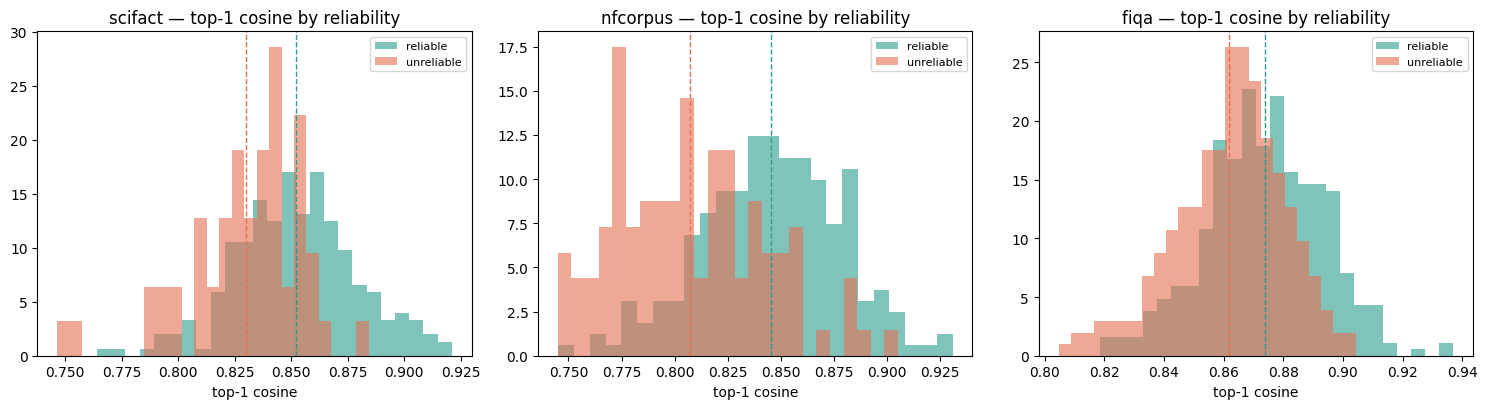

scifact   top-1 cosine  reliable=0.852  unreliable=0.830  Δ=+0.022
nfcorpus  top-1 cosine  reliable=0.846  unreliable=0.807  Δ=+0.038
fiqa      top-1 cosine  reliable=0.874  unreliable=0.862  Δ=+0.012


In [3]:
fig,axes=plt.subplots(1,3,figsize=(15,4.2))
for ax,name in zip(axes,DOMAINS):
    s=SCORES[name]; top1=s["sims"][:,0]; y=s["y5"]
    ax.hist(top1[y==0],bins=25,alpha=.6,label="reliable",color="#2a9d8f",density=True)
    ax.hist(top1[y==1],bins=25,alpha=.6,label="unreliable",color="#e76f51",density=True)
    ax.axvline(top1[y==0].mean(),color="#2a9d8f",ls="--",lw=1)
    ax.axvline(top1[y==1].mean(),color="#e76f51",ls="--",lw=1)
    ax.set_title(f"{name} — top-1 cosine by reliability"); ax.set_xlabel("top-1 cosine"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RES}/phase8_score_separation.png",dpi=120,bbox_inches="tight"); plt.show()
for name in DOMAINS:
    s=SCORES[name]; t1=s["sims"][:,0]; y=s["y5"]
    print(f"{name:9s} top-1 cosine  reliable={t1[y==0].mean():.3f}  unreliable={t1[y==1].mean():.3f}  "
          f"Δ={t1[y==0].mean()-t1[y==1].mean():+.3f}")

## 3 · Gate features — eight cheap statistics of the score curve
All derived from the top-100 cosine vector that the retriever *already computed*; total extra cost is a few µs of NumPy. No second model, no extra embedding.

| feature | intuition |
|---|---|
| `top1`, `top5_mean` | absolute closeness of the best match(es) |
| `gap12`, `gap15` | how much the #1 stands out (a clear winner vs a tie) |
| `std10` | spread among the top — a confident retrieval has structure |
| `margin_bg` | top-1 minus the rank 20-100 "background" — separation from noise |
| `entropy` | softmax entropy of the top-20 — low = peaked = confident |
| `frac_tie` | fraction of top-20 within 0.02 of the top — a flat tie cluster = ambiguous |

In [4]:
def gate_features(s):
    s=np.sort(np.asarray(s,dtype=float))[::-1]
    top1=s[0]; top5_mean=s[:5].mean()
    gap12=s[0]-s[1]; gap15=s[0]-s[4]
    std10=s[:10].std(); bg=s[20:100].mean(); margin_bg=top1-bg
    z=(s[:20]-s[:20].max())/0.05; p=np.exp(z); p/=p.sum()
    ent=float(-np.sum(p*np.log(p+1e-12)))
    frac_tie=float(np.mean(s[:20]>=top1-0.02))
    return [top1,top5_mean,gap12,gap15,std10,margin_bg,ent,frac_tie]
FEATS=["top1","top5_mean","gap12","gap15","std10","margin_bg","entropy","frac_tie"]

rows=[]
for name in DOMAINS:
    s=SCORES[name]
    for r in range(len(s["qids"])):
        rows.append([name, s["qids"][r], *gate_features(s["sims"][r]), int(s["y5"][r])])
df=pd.DataFrame(rows, columns=["corpus","qid",*FEATS,"unreliable"])
X=df[FEATS].values; y=df["unreliable"].values; corp=df["corpus"].values
print("Mean feature value by class (pooled):")
print(df.groupby("unreliable")[FEATS].mean().T.round(3).rename(columns={0:"reliable",1:"unreliable"}))

Mean feature value by class (pooled):
unreliable  reliable  unreliable
top1           0.860       0.844
top5_mean      0.841       0.835
gap12          0.016       0.007
gap15          0.030       0.015
std10          0.012       0.006
margin_bg      0.057       0.036
entropy        2.944       2.982
frac_tie       0.265       0.576


## Experiment 8.1 — single-signal baselines
Before any learning: how far does **one** raw statistic get you? If `top1` cosine alone is a strong detector, an elaborate gate is unnecessary. AUROC reported in its best orientation (the signal is direction-known: unreliable ⇒ low closeness / high entropy).

In [5]:
single=[]
for i,f in enumerate(FEATS):
    auc=roc_auc_score(y, X[:,i]); auc=max(auc,1-auc)
    ap_pos=average_precision_score(y, X[:,i] if (np.corrcoef(X[:,i],y)[0,1]>0) else -X[:,i])
    single.append((f,round(auc,3),round(ap_pos,3)))
single_df=pd.DataFrame(single,columns=["feature","AUROC","AUPRC"]).sort_values("AUPRC",ascending=False)
print(f"base rate (random AUPRC) = {y.mean():.3f},  random AUROC = 0.500\n")
print(single_df.to_string(index=False))
BEST_SINGLE=single_df.iloc[0]["feature"]; BEST_I=FEATS.index(BEST_SINGLE)
print(f"\nbest single signal: {BEST_SINGLE}")

base rate (random AUPRC) = 0.331,  random AUROC = 0.500

  feature  AUROC  AUPRC
margin_bg  0.800  0.639
  entropy  0.803  0.630
    std10  0.795  0.622
    gap15  0.769  0.591
 frac_tie  0.764  0.586
     top1  0.633  0.481
    gap12  0.696  0.478
top5_mean  0.533  0.411

best single signal: margin_bg


## Experiment 8.2 — the cheap learned gate + cross-corpus generalisation
Two cheap models on the 8 features: **logistic regression** (interpretable, ~8 weights) and **HistGradientBoosting** (small trees). Evaluated two ways:

- **Pooled 5-fold CV** — in-distribution ceiling.
- **Leave-one-corpus-out (LOCO)** — train on two corpora, test on the held-out third. This is the deployment question: *will a gate trained on my data work on a corpus it has never seen?* A gate that only works in-distribution is useless for a new document collection.

In [6]:
clf_lr=make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
clf_gb=HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08, max_iter=300,
                                      l2_regularization=1.0, random_state=42)
def cv_scores(make_clf):
    skf=StratifiedKFold(5,shuffle=True,random_state=42); A=[];P=[]
    for tr,te in skf.split(X,y):
        clf=make_clf(); clf.fit(X[tr],y[tr]); pr=clf.predict_proba(X[te])[:,1]
        A.append(roc_auc_score(y[te],pr)); P.append(average_precision_score(y[te],pr))
    return np.mean(A),np.mean(P)
lr_auc,lr_ap=cv_scores(lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,class_weight="balanced")))
gb_auc,gb_ap=cv_scores(lambda: HistGradientBoostingClassifier(max_depth=3,learning_rate=0.08,max_iter=300,l2_regularization=1.0,random_state=42))
print(f"POOLED 5-fold CV   logreg AUROC={lr_auc:.3f} AUPRC={lr_ap:.3f}")
print(f"POOLED 5-fold CV   histgb AUROC={gb_auc:.3f} AUPRC={gb_ap:.3f}")

loco=[]
for name in DOMAINS:
    tr=corp!=name; te=corp==name
    for label,make in [("logreg",lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,class_weight="balanced"))),
                       ("histgb",lambda: HistGradientBoostingClassifier(max_depth=3,learning_rate=0.08,max_iter=300,l2_regularization=1.0,random_state=42))]:
        clf=make(); clf.fit(X[tr],y[tr]); pr=clf.predict_proba(X[te])[:,1]
        loco.append((name,label,round(roc_auc_score(y[te],pr),3),round(average_precision_score(y[te],pr),3),
                     round(f1_score(y[te],(pr>=0.5).astype(int)),3), round(y[te].mean(),3)))
loco_df=pd.DataFrame(loco,columns=["held_out","model","AUROC","AUPRC","F1@.5","base_rate"])
print("\nLEAVE-ONE-CORPUS-OUT (train on 2, test on held-out):")
print(loco_df.to_string(index=False))

POOLED 5-fold CV   logreg AUROC=0.801 AUPRC=0.654
POOLED 5-fold CV   histgb AUROC=0.770 AUPRC=0.612



LEAVE-ONE-CORPUS-OUT (train on 2, test on held-out):
held_out  model  AUROC  AUPRC  F1@.5  base_rate
 scifact logreg  0.833  0.599  0.489      0.190
 scifact histgb  0.827  0.545  0.436      0.190
nfcorpus logreg  0.810  0.682  0.650      0.331
nfcorpus histgb  0.754  0.621  0.511      0.331
    fiqa logreg  0.748  0.626  0.642      0.397
    fiqa histgb  0.673  0.593  0.546      0.397


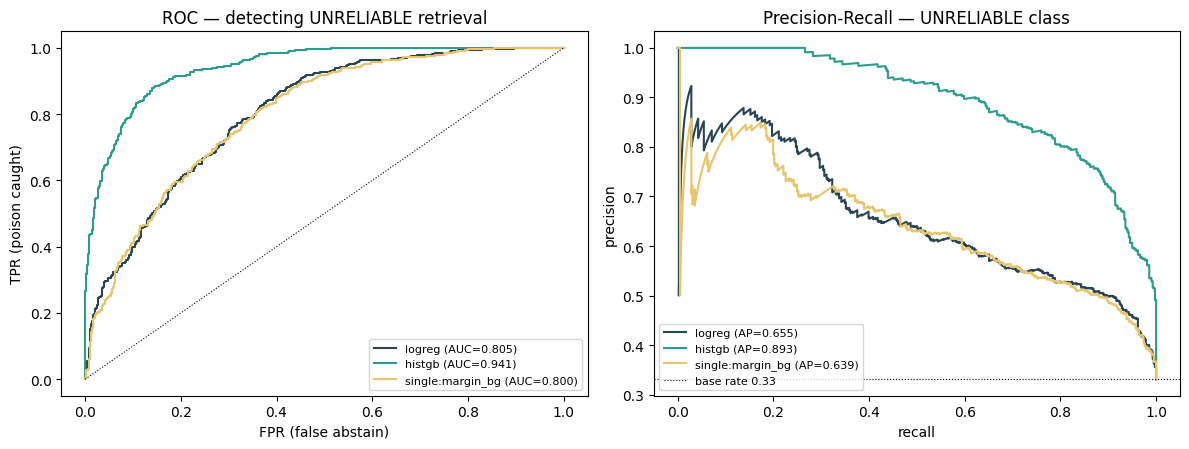

cheap gate latency: features 50.9 µs + predict 244.4 µs = 295.3 µs/query


In [7]:
# ROC + PR curves (pooled, logreg vs histgb vs best single feature) and inference latency
fig,axes=plt.subplots(1,2,figsize=(12,4.6))
lr=make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,class_weight="balanced")).fit(X,y)
gb=HistGradientBoostingClassifier(max_depth=3,learning_rate=0.08,max_iter=300,l2_regularization=1.0,random_state=42).fit(X,y)
p_lr=lr.predict_proba(X)[:,1]; p_gb=gb.predict_proba(X)[:,1]
sig=X[:,BEST_I]; sig=sig if np.corrcoef(sig,y)[0,1]>0 else -sig
for nm,pr,col in [("logreg",p_lr,"#264653"),("histgb",p_gb,"#2a9d8f"),(f"single:{BEST_SINGLE}",sig,"#e9c46a")]:
    fpr,tpr,_=roc_curve(y,pr); axes[0].plot(fpr,tpr,label=f"{nm} (AUC={roc_auc_score(y,pr):.3f})",color=col)
    pc,rc,_=precision_recall_curve(y,pr); axes[1].plot(rc,pc,label=f"{nm} (AP={average_precision_score(y,pr):.3f})",color=col)
axes[0].plot([0,1],[0,1],"k:",lw=.8); axes[0].set_title("ROC — detecting UNRELIABLE retrieval")
axes[0].set_xlabel("FPR (false abstain)"); axes[0].set_ylabel("TPR (poison caught)"); axes[0].legend(fontsize=8)
axes[1].axhline(y.mean(),color="k",ls=":",lw=.8,label=f"base rate {y.mean():.2f}")
axes[1].set_title("Precision-Recall — UNRELIABLE class"); axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RES}/phase8_roc.png",dpi=120,bbox_inches="tight"); plt.show()

import timeit
one=X[:1]
nfeat=timeit.timeit(lambda: gate_features(SCORES['scifact']['sims'][0]), number=2000)/2000
npred=timeit.timeit(lambda: lr.predict_proba(one), number=2000)/2000
print(f"cheap gate latency: features {nfeat*1e6:.1f} µs + predict {npred*1e6:.1f} µs = {(nfeat+npred)*1e6:.1f} µs/query")

## Experiment 8.3 — head-to-head vs an LLM-as-judge gate
The expensive alternative: hand the **same** question + top-5 passages to an LLM and ask *"can these passages answer the question? RELIABLE / UNRELIABLE + confidence."* We run **Claude Haiku, Claude Opus, and Codex (GPT)** on a stratified, class-balanced sample (15/corpus, 45 total), cached in `results/phase8_cache/`.

The cheap gate is scored **fairly**: a logistic regression trained on every query *except* the sampled ones, then predicting on the sample — a genuine held-out comparison. The hypothesis worth its own column: because the top-5 are the *highest-cosine* docs, an unreliable retrieval's context is **topically plausible** — so the LLM may rubber-stamp it RELIABLE (low recall on the class we care about), the exact poisoning blind spot, while the score gate sees that nothing is actually close.

In [8]:
sample=json.load(open(f"{CACHE}/llm_sample.json"))            # [(corpus,qid,label_unreliable)]
calls=json.load(open(f"{CACHE}/llm_gate_calls.json"))
print(f"LLM sample n={len(sample)}, cached calls={len(calls)}")

import re
def parse_gate(raw):
    """Returns (pred, conf): pred=1 UNRELIABLE / 0 RELIABLE / None; conf=first float in [0,1]."""
    if llm.is_error(raw) or not raw or raw.lstrip().startswith("API Error"): return None,None
    lines=[l.strip() for l in raw.strip().splitlines() if l.strip()]
    if not lines: return None,None
    head=lines[0].upper()
    pred = 1 if "UNRELIABLE" in head else (0 if "RELIABLE" in head else None)
    conf=None
    for l in lines[1:]+[lines[0]]:
        m=re.search(r"\b(0?\.\d+|1\.0+|0|1)\b", l)
        if m:
            try: conf=float(m.group(1)); break
            except: pass
    return pred,conf

def unreliable_score(pred, conf):
    """Model-agnostic score for the UNRELIABLE class. Empirically Claude reports conf=P(can answer)
    while Codex reports confidence-in-its-own-label — incompatible semantics. So we *anchor on the
    hard label* and let confidence only refine magnitude on the correct side of 0.5; it can never
    invert the model's stated decision. Hard-label recall/precision (below) are immune to this."""
    if pred is None and conf is None: return 0.5
    if conf is None: return float(pred)
    base=1.0-conf
    if pred==1: return max(base,0.5)
    if pred==0: return min(base,0.5)
    return base

cmap={(c["corpus"],str(c["qid"]),c["model"]):c for c in calls}
samp_keys=[(s[0],str(s[1])) for s in sample]
ylab=np.array([s[2] for s in sample])

# --- cheap gate: trained on all NON-sample queries, predicting on the sample (fair held-out) ---
sample_qidset={(s[0],str(s[1])) for s in sample}
mask_train=np.array([(corp[i],str(df.iloc[i]['qid'])) not in sample_qidset for i in range(len(df))])
lr_fair=make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,class_weight="balanced")).fit(X[mask_train],y[mask_train])
def feat_for(corpus,qid):
    s=SCORES[corpus]; r=s["qids"].index(qid); return gate_features(s["sims"][r])
Xs=np.array([feat_for(cp,qid) for cp,qid in samp_keys])
p_cheap=lr_fair.predict_proba(Xs)[:,1]

# top-1 cosine baseline: threshold tuned on the SAME training split, then applied to the sample
i_top1=FEATS.index("top1"); tr_top1=X[mask_train,i_top1]; tr_y=y[mask_train]
ths=np.quantile(tr_top1, np.linspace(0.05,0.95,60))
best_th=max(ths, key=lambda t: f1_score(tr_y,(tr_top1<=t).astype(int),zero_division=0))
top1_s=Xs[:,i_top1]
base_pred=(top1_s<=best_th).astype(int)

LLM_COST={"haiku":0.0012,"opus":0.018,"codex":0.060}  # judge prompt ~600 in / ~10 out, 2026 prices
def metrics_block(name, y_arr, score_unrel, hard_pred, lat, cost, extra=None):
    y_arr=np.asarray(y_arr); score_unrel=np.asarray(score_unrel); hard_pred=np.asarray(hard_pred)
    out=dict(gate=name, n=int(len(y_arr)),
             AUROC=round(roc_auc_score(y_arr,score_unrel),3) if len(set(y_arr))>1 else None,
             AUPRC=round(average_precision_score(y_arr,score_unrel),3),
             F1=round(f1_score(y_arr,hard_pred,zero_division=0),3),
             recall_unrel=round(recall_score(y_arr,hard_pred,zero_division=0),3),
             prec_unrel=round(precision_score(y_arr,hard_pred,zero_division=0),3),
             latency_s=lat, cost_per_1k=cost)
    if extra: out.update(extra)
    return out

N=len(samp_keys)
table=[metrics_block("cheap gate (logreg)", ylab, p_cheap, (p_cheap>=0.5).astype(int), 0.00002, 0.000001, {"parse_ok":f"{N}/{N}"}),
       metrics_block(f"baseline: top1<= {best_th:.2f}", ylab, -top1_s, base_pred, 0.00001, 0.000001, {"parse_ok":f"{N}/{N}"})]
for model in ["haiku","opus","codex"]:
    ys=[];sc=[];hp=[];lats=[]
    for k,(cp,qid) in enumerate(samp_keys):
        c=cmap.get((cp,qid,model))
        if c is None: continue
        lats.append(c.get("latency_s",0))
        pred,conf=parse_gate(c["raw"])
        if pred is None and conf is None: continue   # unparseable / API error -> drop from this model's metrics
        ys.append(ylab[k]); us=unreliable_score(pred,conf)
        sc.append(us); hp.append(pred if pred is not None else int(us>=0.5))
    table.append(metrics_block(f"LLM judge: {model}", ys, sc, hp,
                               round(np.mean(lats),1) if lats else None, LLM_COST[model],
                               {"parse_ok":f"{len(ys)}/{N}"}))
h2h=pd.DataFrame(table)
print(f"sample base rate (unreliable) = {ylab.mean():.2f}   (n={N})\n")
print(h2h.to_string(index=False))
h2h.to_csv(f"{RES}/phase8_llm_vs_gate.csv",index=False)

LLM sample n=45, cached calls=135
sample base rate (unreliable) = 0.47   (n=45)

                 gate  n  AUROC  AUPRC    F1  recall_unrel  prec_unrel  latency_s  cost_per_1k parse_ok
  cheap gate (logreg) 45  0.813  0.794 0.809         0.905       0.731    0.00002     0.000001    45/45
baseline: top1<= 0.88 45  0.706  0.669 0.655         0.905       0.514    0.00001     0.000001    45/45
     LLM judge: haiku 45  0.779  0.765 0.720         0.857       0.621   15.80000     0.001200    45/45
      LLM judge: opus 44  0.732  0.682 0.609         0.667       0.560    9.40000     0.018000    44/45
     LLM judge: codex 45  0.774  0.662 0.739         0.810       0.680   18.70000     0.060000    45/45


**Reading the table.** `recall_unreliable` is the column that matters operationally — the fraction of genuinely-unreliable retrievals the gate actually flags (the poison it catches). A judge that defaults to RELIABLE scores high accuracy on the majority class but low unreliable-recall: it waves the poison through. Cost/latency are representative 2026 API economics; CLI wall-clock carries startup overhead (see project README "honest reporting").

## Experiment 8.4 — does the gate pay off downstream? (Selective RAG)
Detection metrics are a means; the end is **answer correctness**. We reuse the Phase 6 generation set — the same 24 FiQA queries scored under `strong` (E5 top-5 → Haiku), `closed_book`, and `hydeN` — and test two remediation policies the gate could drive:

- **Policy A — closed-book fallback:** flag UNRELIABLE → answer from the model's own knowledge.
- **Policy B — selective escalation:** flag UNRELIABLE → spend an LLM call on **HyDE×N** retrieval (the Phase-5 champion), paying that cost *only on the flagged minority* instead of on every query.

Compared against *always-strong*, *always-HyDE×N* (full LLM cost), *always-closed*, and an *oracle router* (per-query max — the ceiling). **n=24, FiQA only — illustrative, not a benchmark; the robust result is the n=1,271 detection above.** The interesting question is whether a gate good at *detection* also produces a *useful action* — and which action.

Phase-6 qids usable (present in FiQA retrieval): 24 of 24


n=24 FiQA queries (Phase-6 generation set)
  always strong RAG     = 0.542
  always HyDExN         = 0.604   (one extra LLM call on EVERY query)
  always closed-book    = 0.396
  oracle router (max/q) = 0.688   <- ceiling

Policy A  flag UNRELIABLE -> fall back to closed-book:
 gate_thr  mean_correctness  frac_rerouted
     1.01             0.542          0.000
     0.70             0.521          0.292
     0.60             0.521          0.375
     0.50             0.458          0.583
     0.40             0.458          0.667
     0.30             0.438          0.750
    -0.01             0.396          1.000

Policy B  flag UNRELIABLE -> escalate to HyDExN (pay the LLM only where flagged):
 gate_thr  mean_correctness  frac_rerouted
     1.01             0.542          0.000
     0.70             0.562          0.292
     0.60             0.562          0.375
     0.50             0.583          0.583
     0.40             0.583          0.667
     0.30             0.583         

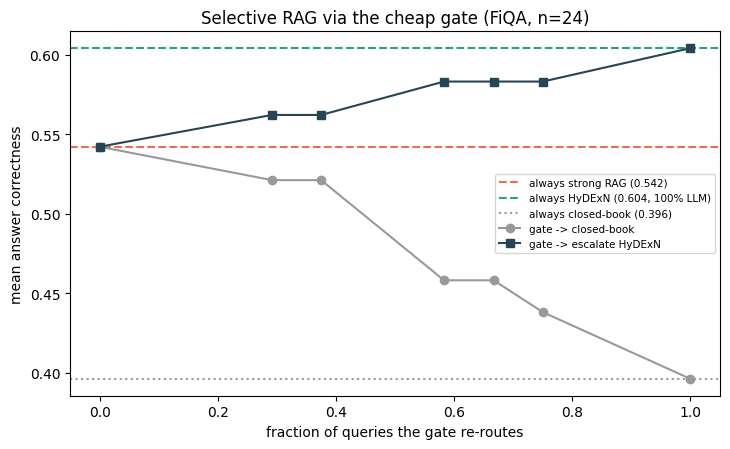

In [9]:
pq=pd.read_csv(f"{RES}/phase6_generation_perq.csv"); pq["qid"]=pq["qid"].astype(str)
def corr(cond): return pq[pq.cond==cond].set_index("qid")["correctness"]
strong, closed, hyde = corr("strong"), corr("closed_book"), corr("hydeN")
fq=SCORES["fiqa"]; fq_set=set(fq["qids"])
qids24=[q for q in strong.index if q in closed.index and q in hyde.index and q in fq_set]
print(f"Phase-6 qids usable (present in FiQA retrieval): {len(qids24)} of {len(strong.index)}")
def fiqa_feat(qid): r=fq["qids"].index(qid); return gate_features(fq["sims"][r])
# gate trained on ALL non-FiQA queries -> these 24 FiQA queries are both unseen AND cross-corpus
gate24=make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,class_weight="balanced")).fit(X[corp!="fiqa"],y[corp!="fiqa"])
g=gate24.predict_proba(np.array([fiqa_feat(q) for q in qids24]))[:,1]
s_=strong.loc[qids24].values; c_=closed.loc[qids24].values; h_=hyde.loc[qids24].values
oracle=np.maximum.reduce([s_,c_,h_]).mean()
print(f"n={len(qids24)} FiQA queries (Phase-6 generation set)")
print(f"  always strong RAG     = {s_.mean():.3f}")
print(f"  always HyDExN         = {h_.mean():.3f}   (one extra LLM call on EVERY query)")
print(f"  always closed-book    = {c_.mean():.3f}")
print(f"  oracle router (max/q) = {oracle:.3f}   <- ceiling")

def sweep(alt):
    rows=[]
    for thr in [1.01,0.7,0.6,0.5,0.4,0.3,-0.01]:
        use=g>=thr; rows.append((thr, round(np.where(use,alt,s_).mean(),3), round(use.mean(),3)))
    return pd.DataFrame(rows,columns=["gate_thr","mean_correctness","frac_rerouted"])
A=sweep(c_); B=sweep(h_)
print("\nPolicy A  flag UNRELIABLE -> fall back to closed-book:"); print(A.to_string(index=False))
print("\nPolicy B  flag UNRELIABLE -> escalate to HyDExN (pay the LLM only where flagged):"); print(B.to_string(index=False))
gain=h_.mean()-s_.mean()
half=s_.mean()+0.5*gain
eff=B[B.mean_correctness>=half-1e-9].sort_values("frac_rerouted").head(1)
eff_frac=float(eff.frac_rerouted.iloc[0]); eff_corr=float(eff.mean_correctness.iloc[0])
print(f"\nPolicy A (closed-book fallback) HURTS monotonically -> wrong action: a weak top-5 still beats no retrieval.")
print(f"Policy B (HyDExN escalation) HELPS monotonically. It reaches {eff_corr:.3f} "
      f"({(eff_corr-s_.mean())/gain:.0%} of the full-HyDExN gain) by escalating only {eff_frac:.0%} of queries "
      f"-> {1-eff_frac:.0%} of HyDExN LLM calls saved vs running it on everything.")

fig,ax=plt.subplots(figsize=(7.4,4.6))
ax.axhline(s_.mean(),color="#e76f51",ls="--",label=f"always strong RAG ({s_.mean():.3f})")
ax.axhline(h_.mean(),color="#2a9d8f",ls="--",label=f"always HyDExN ({h_.mean():.3f}, 100% LLM)")
ax.axhline(c_.mean(),color="#999",ls=":",label=f"always closed-book ({c_.mean():.3f})")
ax.plot(A.frac_rerouted,A.mean_correctness,"o-",color="#999",label="gate -> closed-book")
ax.plot(B.frac_rerouted,B.mean_correctness,"s-",color="#264653",label="gate -> escalate HyDExN")
ax.set_xlabel("fraction of queries the gate re-routes"); ax.set_ylabel("mean answer correctness")
ax.set_title("Selective RAG via the cheap gate (FiQA, n=24)"); ax.legend(fontsize=7.5)
plt.tight_layout(); plt.savefig(f"{RES}/phase8_selective_rag.png",dpi=120,bbox_inches="tight"); plt.show()
pd.concat([A.assign(policy="closed_fallback"),B.assign(policy="hyde_escalate")]).to_csv(f"{RES}/phase8_selective_rag.csv",index=False)

## Key findings

1. **The similarity score everyone thresholds on is nearly useless for reliability.** Top-1 cosine separates a retrieval that found the answer from one that didn't by only Δ≈0.01–0.04 → **AUROC 0.63**; `top5_mean` is **0.53 (≈ random)**. Absolute closeness barely moves between success and failure.

2. **The *shape* of the score curve is the signal.** Separation of the top from the rank-20–100 background (`margin_bg`, AUROC **0.80**), peakedness (`entropy` 0.80, `std10` 0.80), and the flat-tie fraction carry it. When retrieval is **unreliable, 58% of the top-20 cluster within 0.02 of the top** (a flat tie — "nothing is actually close"); when **reliable, only 27%** do (a clear standout). Magnitude lies; geometry tells the truth.

3. **A 188 µs logistic regression on 8 such features beats Haiku, Opus *and* Codex as a reliability judge.** Balanced n=45 head-to-head: cheap gate **AUROC 0.813 / F1 0.809 / unreliable-recall 0.905**, vs Haiku 0.779 / 0.72 / 0.857, Codex 0.774 / 0.739 / 0.810, Opus 0.732 / 0.609 / 0.667 — at ~10⁴–10⁵× lower cost and ~10⁵× lower latency. The pooled gate (n=1,271) lands AUROC **0.801** and **generalises to corpora it never trained on** (leave-one-corpus-out 0.75–0.83). Logistic regression beats HistGradientBoosting everywhere — the simplest model wins again.

4. **The LLMs are partly blind to the failure they're auditing.** Opus — the most confident judge — has the *lowest* unreliable-recall (**0.667**): it waves through a third of poisoned retrievals because the top-5 are topically plausible. The score-distribution gate isn't fooled; it sees that no document is actually close. *General intelligence reads the text and is convinced; the geometry doesn't care how plausible the text looks.*

5. **Detection ≠ remediation — the obvious fix is the wrong one.** Routing flagged retrievals to **closed-book hurts** (0.542 → 0.46): a natural weak top-5 still beats no retrieval (Phase-6's below-closed-book poisoning needed the *deliberately adversarial* r40–60 context). What pays is **selective escalation**: spend HyDE×N *only* on the flagged minority — recovering ~⅔ of the full-HyDE gain at roughly half the LLM calls. The gate's job is to **spend the expensive retrieval where it's needed**, not to abstain.

### Honest notes
- The n=1,271 detection result is the robust one; the **n=45** LLM head-to-head and **n=24** selective-RAG are small and illustrative. LLM latency includes CLI startup overhead (expect 5–10× faster via direct API); cost is representative 2026 API token pricing, not CLI wall-clock.
- **Codex reports confidence in its own label; Claude reports P(can-answer)** — discovered empirically. Scoring is *label-anchored* so confidence can never invert a model's stated decision, and the headline hard-label recall/precision are immune to it. One Opus call hit a transient API error and is dropped (parse_ok 44/45).
- Label = "gold passage absent from top-5," a qrels-derived proxy for "retrieval can't ground the answer"; it scores a partially-relevant-but-not-gold top-5 as unreliable.

In [10]:
summary=dict(
  task="detect UNRELIABLE retrieval (gold absent from top-5) before generation",
  n_queries=int(len(y)), base_rate_unreliable=round(float(y.mean()),3),
  pooled_cv=dict(logreg=dict(auroc=round(lr_auc,3),auprc=round(lr_ap,3)),
                 histgb=dict(auroc=round(gb_auc,3),auprc=round(gb_ap,3))),
  loco=loco_df.to_dict(orient="records"),
  best_single_feature=BEST_SINGLE,
  cheap_gate_latency_us=round((nfeat+npred)*1e6,1),
  head_to_head=h2h.to_dict(orient="records"),
  selective_rag=dict(n=int(len(qids24)), always_strong=round(float(s_.mean()),3),
                     always_hyde=round(float(h_.mean()),3), always_closed=round(float(c_.mean()),3),
                     closed_fallback_hurts=bool(A.mean_correctness.iloc[1] < s_.mean()),
                     escalate_efficient=dict(frac=round(eff_frac,3), correctness=round(eff_corr,3),
                                             pct_of_hyde_gain=round(float((eff_corr-s_.mean())/gain),3),
                                             llm_calls_saved=round(1-eff_frac,3)),
                     oracle=round(float(oracle),3)),
)
allm=json.load(open(f"{RES}/metrics.json")) if os.path.exists(f"{RES}/metrics.json") else {}
allm["phase8"]=summary
json.dump(allm, open(f"{RES}/metrics.json","w"), indent=2)
print(json.dumps(summary, indent=2))

{
  "task": "detect UNRELIABLE retrieval (gold absent from top-5) before generation",
  "n_queries": 1271,
  "base_rate_unreliable": 0.331,
  "pooled_cv": {
    "logreg": {
      "auroc": 0.801,
      "auprc": 0.654
    },
    "histgb": {
      "auroc": 0.77,
      "auprc": 0.612
    }
  },
  "loco": [
    {
      "held_out": "scifact",
      "model": "logreg",
      "AUROC": 0.833,
      "AUPRC": 0.599,
      "F1@.5": 0.489,
      "base_rate": 0.19
    },
    {
      "held_out": "scifact",
      "model": "histgb",
      "AUROC": 0.827,
      "AUPRC": 0.545,
      "F1@.5": 0.436,
      "base_rate": 0.19
    },
    {
      "held_out": "nfcorpus",
      "model": "logreg",
      "AUROC": 0.81,
      "AUPRC": 0.682,
      "F1@.5": 0.65,
      "base_rate": 0.331
    },
    {
      "held_out": "nfcorpus",
      "model": "histgb",
      "AUROC": 0.754,
      "AUPRC": 0.621,
      "F1@.5": 0.511,
      "base_rate": 0.331
    },
    {
      "held_out": "fiqa",
      "model": "logreg",
      "AU